In [1]:
import tensorflow as tf
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pawankumargunjan/imdb-review")

print("Path to dataset files:", path)

100%|██████████| 111M/111M [00:03<00:00, 32.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pawankumargunjan/imdb-review/versions/3


In [3]:
import os

files = os.listdir(path)
print(files)

['aclImdb']


In [4]:
import os
import pandas as pd

# The 'path' variable is already defined from previous cells:
# path = '/root/.cache/kagglehub/datasets/pawankumargunjan/imdb-review/versions/3'

# The actual dataset files are inside the 'aclImdb' subdirectory
aclimdb_path = os.path.join(path, "aclImdb")

def load_reviews_from_folder(folder_path):
    reviews = []
    labels = []

    for sentiment in ['pos', 'neg']:
        sentiment_path = os.path.join(folder_path, sentiment)
        for filename in os.listdir(sentiment_path):
            if filename.endswith(".txt"):
                file_path = os.path.join(sentiment_path, filename)
                with open(file_path, 'r', encoding='utf-8') as f:
                    reviews.append(f.read())
                labels.append(1 if sentiment == 'pos' else 0)
    return pd.DataFrame({'review': reviews, 'sentiment': labels})

# Load training data
train_path = os.path.join(aclimdb_path, 'train')
train_df = load_reviews_from_folder(train_path)

# Load test data
test_path = os.path.join(aclimdb_path, 'test')
test_df = load_reviews_from_folder(test_path)

print("Train DataFrame head:")
print(train_df.head())
print("\nTest DataFrame head:")
print(test_df.head())

Train DataFrame head:
                                              review  sentiment
0  "Jake Speed" is a fine movie with a wonderful ...          1
1  I have seen The Perfect Son about three times....          1
2  The Thing About My Folks is a wonderful film a...          1
3  I've just watch 2 films of Pang brothers, The ...          1
4  Soldier isn't a great movie, and everyone that...          1

Test DataFrame head:
                                              review  sentiment
0  This was an interesting study in societal sexu...          1
1  While I agree that this movie lacks any real s...          1
2  When I saw the first preview for this, I nearl...          1
3  I've heard a few comments, particularly from p...          1
4  SO good, the acting, cutting, directing in the...          1


In [5]:
import tensorflow as tf

batch_size = 32

# Convert Pandas DataFrames to TensorFlow Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_df['review'], train_df['sentiment']))
test_dataset = tf.data.Dataset.from_tensor_slices((test_df['review'], test_df['sentiment']))

# Apply shuffle and batch
train_dataset = train_dataset.shuffle(10000).batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

In [6]:
review, sentiment = next(iter(train_dataset))
print('Review:\n', review[0].numpy().decode('utf-8'))
print('Sentiment:', sentiment[0].numpy())
print(sentiment)

Review:
 Full House is a great family show. However, after watching some episodes over and over again I've realized that they're incredibly boring and they seem to shelter themselves from the outside world a lot. Yes, there is a lot of comedy, but there are times when it's incredibly cheesy. It's not like I hate it, but just don't watch them over and over again because they get old quick. Probably the best season is the first.<br /><br />Full House is about widower Danny Tanner(Bob Saget)and his three daughters D.J. (Candace Cameron) Stephanie (Jodie Sweetin) and Michelle (Mary-Kate and Ashley). When Danny's wife dies the he is in need of some help. So, his best friend Joey (Dave Coulier) and the girls' Uncle Jesse (John Stamos) moves in with them. Once they live there together they find they can't live without each other. <br /><br />Full House reminds you just how important family is and that you can always go home again.
Sentiment: 1
tf.Tensor([1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

In [9]:
encoder = tf.keras.layers.TextVectorization()
encoder.adapt(train_dataset.map(lambda review, _:review))

vocabulary = np.array(encoder.get_vocabulary())

org_review = review.numpy()
encoded_review = encoder(org_review).numpy()
decoded_review = ' '.join(vocabulary[encoded_review[0]])

print('Review:\n', org_review)
print('Encoded review:\n', encoded_review)
print('Decoded review:\n', decoded_review)

print('Review:\n', org_review)
print('Encoded review:\n', encoded_review)

Review:
 [b"Full House is a great family show. However, after watching some episodes over and over again I've realized that they're incredibly boring and they seem to shelter themselves from the outside world a lot. Yes, there is a lot of comedy, but there are times when it's incredibly cheesy. It's not like I hate it, but just don't watch them over and over again because they get old quick. Probably the best season is the first.<br /><br />Full House is about widower Danny Tanner(Bob Saget)and his three daughters D.J. (Candace Cameron) Stephanie (Jodie Sweetin) and Michelle (Mary-Kate and Ashley). When Danny's wife dies the he is in need of some help. So, his best friend Joey (Dave Coulier) and the girls' Uncle Jesse (John Stamos) moves in with them. Once they live there together they find they can't live without each other. <br /><br />Full House reminds you just how important family is and that you can always go home again."
 b"Although this film put Davis on the map due to her bril

Building the model

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,), dtype=tf.string),
    encoder,
    tf.keras.layers.Embedding(input_dim=len(encoder.get_vocabulary()), output_dim=64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)), # Added return_sequences=True
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 64)       │     7,801,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, None, 128)      │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,912,705 (30.18 MB)

 Trainable params: 7,912,705 (30.18 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

Model Training

In [13]:
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset,
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 116s 139ms/step - accuracy: 0.7165 - loss: 0.5065 - val_accuracy: 0.7058 - val_loss: 0.4984
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 138ms/step - accuracy: 0.8687 - loss: 0.3012 - val_accuracy: 0.8259 - val_loss: 0.3922
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 140ms/step - accuracy: 0.9364 - loss: 0.1682 - val_accuracy: 0.8628 - val_loss: 0.3464
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 138ms/step - accuracy: 0.9663 - loss: 0.0980 - val_accuracy: 0.8657 - val_loss: 0.3809
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 138ms/step - accuracy: 0.9826 - loss: 0.0547 - val_accuracy: 0.8602 - val_loss: 0.4535


model performance presentation

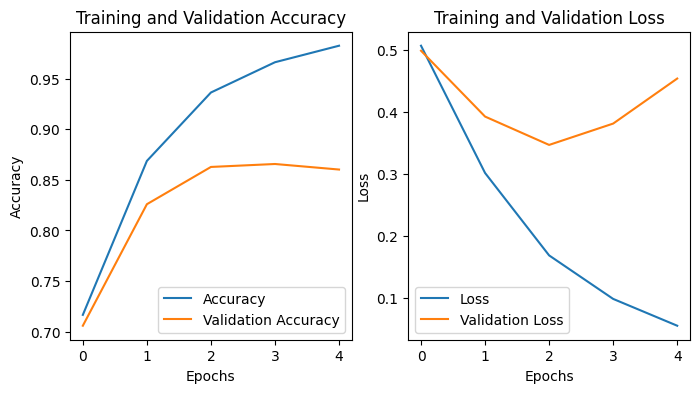

In [14]:
history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

loss = history_dict['loss']
val_loss = history_dict['val_loss']

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(acc)
plt.plot(val_acc)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Accuracy', 'Validation Accuracy'])

plt.subplot(1, 2, 2)
plt.plot(loss)
plt.plot(val_loss)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Loss', 'Validation Loss'])

plt.show()

Model testing

In [15]:
sample_text = (
    '''The movie  by aventures was so good and the animation are so dope.
    I would recommend my friends to watch it.'''
)
sample_text_tensor = tf.constant([sample_text], dtype=tf.string)

predictions = model.predict(sample_text_tensor)

print("Prediction probability:", predictions[0])

if predictions[0] > 0.5:
    print('The review is positive')
else:
    print('The review is negative')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
Prediction probability: [4.4652815]
The review is positive
